In [8]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 샘플 문장 데이터 (긍정/부정 감정 포함)
sentences = [
    "I love this movie",             # 긍정 → 1
    "This dinner was amazing",       # 긍정 → 1
    "I really enjoyed the concert",  # 긍정 → 1
    "I hate waiting in line",        # 부정 → 0
    "The food was terrible"          # 부정 → 0
]
labels = np.array([1, 1, 1, 0, 0])

# 텍스트를 정수 시퀀스로 변환
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(sentences)

# 시퀀스 길이를 맞추기 위해 패딩 적용
max_len = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')

# 임베딩 설정
vocab_size = len(word_index) + 1  # +1 for padding index 0
embedding_dim = 3  # 시각화를 위해 2 또는 3 사용 가능

# 모델 구성
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Flatten(),
    Dense(1, activation='sigmoid')  # 감정 분류
])

# 컴파일 및 학습
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 학습
model.fit(padded_sequences, labels, epochs=100, verbose=0)

# 임베딩 레이어의 가중치 추출
embedding_weights = model.layers[0].get_weights()[0]

# 단어별 임베딩 벡터 출력
print("\n✅ 학습된 워드 임베딩\n")
for word, i in sorted(word_index.items(), key=lambda x: x[0]):  # 알파벳 순 정렬
    vec = embedding_weights[i]
    vec_str = ", ".join(f"{x: .4f}" for x in vec)
    print(f"{word:12}: [{vec_str}]")


# # 학습 데이터로 예측 테스트
# predictions = model.predict(padded_sequences)
# print("\n")

# # 결과 출력
# for sent, pred in zip(sentences, predictions):
#     print(f"{sent} → 예측 확률: {pred[0]:.4f} → {'긍정' if pred[0] > 0.5 else '부정'}")


✅ 학습된 워드 임베딩

amazing     : [-0.1341,  0.1122,  0.1023]
concert     : [ 0.1261,  0.1044, -0.1086]
dinner      : [-0.0957, -0.0525, -0.0944]
enjoyed     : [-0.1231,  0.1407,  0.0580]
food        : [ 0.1241,  0.1162,  0.0954]
hate        : [ 0.1122,  0.0642,  0.1124]
i           : [-0.0463,  0.0451,  0.0634]
in          : [ 0.1407, -0.1231, -0.0667]
line        : [-0.1053, -0.1143,  0.1279]
love        : [-0.1108, -0.1243, -0.0590]
movie       : [-0.0699,  0.0944,  0.0571]
really      : [-0.0883, -0.0882, -0.1011]
terrible    : [ 0.1461, -0.0573, -0.0893]
the         : [ 0.0497,  0.0132, -0.0288]
this        : [-0.1759,  0.1819,  0.1345]
waiting     : [ 0.0881, -0.1159, -0.1384]
was         : [ 0.0345, -0.0385,  0.0276]


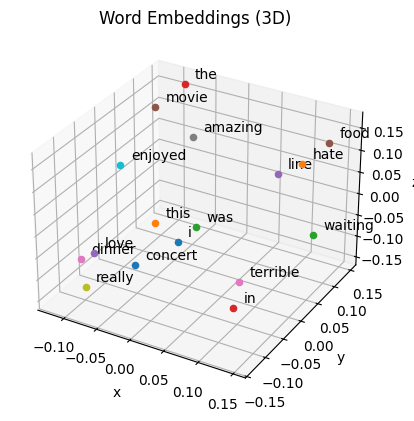

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

if embedding_dim == 3:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    for word, i in word_index.items():
        x, y, z = embedding_weights[i]
        ax.scatter(x, y, z)
        ax.text(x + 0.01, y + 0.01, z + 0.01, word)
    ax.set_title("Word Embeddings (3D)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    plt.show()